# <h1 style="font-size: 48px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #723d46; color: #e26d5c; text-align: center; border-radius: 150px 150px;"><b>Pycaret model evaluation<b></h1>

It should be a short evaluation to determine which model is the best. Afterward, you will know which model or models to focus on.

# Table of contents
- [Data / Package Import ](#1)
- [Little preprocessing](#2)
- [Very short EDA for Threshold](#3)
- [Initializing and Training](#4)
- [Tuning](#5)
    - [LightGBM](#51)
        - [LGMB evaluation](#511)
    - [CatBoost](#52)
        - [CatBoost evaluation](#531)
    - [XGBoost](#53)
        - [XGBoost evaluation](#531) 
            

# <a name="1"></a><h1 style="font-size: 36px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #e26d5c; color:#ffe1a8; text-align: center; border-radius: 50px 50px;"><b>Data / Package Import </b></h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.6/483.6 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... - \ | / - \ | done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 58.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 75.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 18.2

In [2]:
from pycaret.classification import *

In [3]:
df = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
print(df.shape)
df.head()

(617, 58)


,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


# <a name="2"></a><h1 style="font-size: 36px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #e26d5c; color:#ffe1a8; text-align: center; border-radius: 50px 50px;"><b>Little preprocessing </b></h1>

- Id is useless for predictions so we leave it out

In [4]:
df = df.iloc[:,1:]
df.shape

(617, 57)

# <a name="3"></a><h1 style="font-size: 36px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #e26d5c; color:#ffe1a8; text-align: center; border-radius: 50px 50px;"><b>Very short EDA for Threshold</b></h1>

(array([509.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 108.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

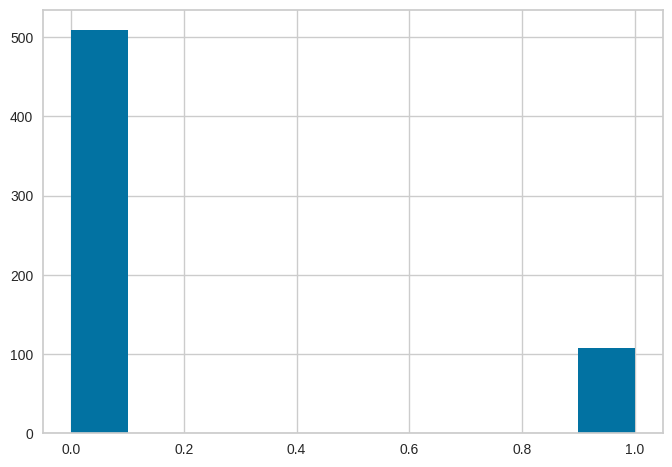

In [5]:
plt.hist(df['Class'])


In [6]:
count_1 = df['Class'].sum()
count_0 = df['Class'].count() - count_1

# Calculate the ratio
ratio = count_1 / count_0
ratio

0.21218074656188604

# <a name="4"></a><h1 style="font-size: 36px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #e26d5c; color:#ffe1a8; text-align: center; border-radius: 50px 50px;"><b>Initializing and Training</b></h1>

In [7]:
clf1 = setup(data = df, target = 'Class')
best = compare_models(n_select = 3, probability_threshold = ratio)

,Description,Value
0,Session id,8428
1,Target,Class
2,Target type,Binary
3,Original data shape,"(617, 57)"
4,Transformed data shape,"(617, 57)"
5,Transformed train set shape,"(431, 57)"
6,Transformed test set shape,"(186, 57)"
7,Ordinal features,1
8,Numeric features,55
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9352,0.9679,0.7911,0.8550,0.8104,0.7719,0.7804,0.7660
catboost,CatBoost Classifier,0.9329,0.9665,0.8696,0.8071,0.8246,0.7843,0.7942,8.2330
xgboost,Extreme Gradient Boosting,0.9260,0.9624,0.8054,0.7938,0.7911,0.7467,0.7525,0.2240
gbc,Gradient Boosting Classifier,0.9004,0.9459,0.7393,0.7372,0.7203,0.6611,0.6731,0.4520
et,Extra Trees Classifier,0.8841,0.9643,0.9214,0.6254,0.7384,0.6693,0.6948,0.3650
lda,Linear Discriminant Analysis,0.8747,0.8763,0.6196,0.6740,0.6322,0.5584,0.5674,0.1010
dt,Decision Tree Classifier,0.8679,0.7574,0.5875,0.6656,0.6030,0.5266,0.5408,0.1010
ridge,Ridge Classifier,0.8678,0.0000,0.3643,0.8276,0.4774,0.4175,0.4773,0.0730
rf,Random Forest Classifier,0.8656,0.9515,0.9071,0.5976,0.7091,0.6299,0.6611,0.4240
nb,Naive Bayes,0.8469,0.8191,0.3571,0.6644,0.4507,0.3705,0.4023,0.1000


Processing:   0%|          | 0/71 [00:00<?, ?it/s]

- a look at the top 3

In [8]:
print(best)

[CustomProbabilityThresholdClassifier(boosting_type='gbdt', class_weight=None,
                                     classifier=LGBMClassifier(boosting_type='gbdt',
                                                               class_weight=None,
                                                               colsample_bytree=1.0,
                                                               importance_type='split',
                                                               learning_rate=0.1,
                                                               max_depth=-1,
                                                               min_child_samples=20,
                                                               min_child_weight=0.001,
                                                               min_split_gain=0.0,
                                                               n_estimators=100,
                                                               n_jobs=-1,
            

# <a name="5"></a><h1 style="font-size: 36px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #e26d5c; color:#ffe1a8; text-align: center; border-radius: 50px 50px;"><b>Tuning</b></h1>

- Tuning every model by its own to have a comparison in the end
- ad metric Log Loss

In [9]:
from sklearn.metrics import log_loss
add_metric('logloss', 'Log Loss', log_loss, greater_is_better = False)

Name                                                       Log Loss
Display Name                                               Log Loss
Score Function                <function log_loss at 0x7ebdc52601f0>
Scorer               make_scorer(log_loss, greater_is_better=False)
Target                                                         pred
Args                                                             {}
Greater is Better                                             False
Multiclass                                                     True
Custom                                                         True
Name: logloss, dtype: object

## <a name="51"></a><h1 style="font-size: 24px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #ffe1a8; color:#C9CBA3; text-align: center; border-radius: 50px 50px;"><b>LightGBM</b></h1> 

In [10]:
# train model
lgbm = create_model('lightgbm')

# tune model 
tuned_dt = tune_model(lgbm, optimize = 'logloss', n_iter=25)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8636,0.9306,0.6250,0.6250,0.6250,0.5417,0.5417,4.9150
1,0.9535,0.9444,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
2,0.9535,0.9841,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
3,0.9302,0.9444,0.5714,1.0000,0.7273,0.6906,0.7263,2.5147
4,0.9767,0.9881,1.0000,0.8750,0.9333,0.9193,0.9223,0.8382
5,0.9070,0.9841,0.5714,0.8000,0.6667,0.6143,0.6261,3.3529
6,0.8837,0.9929,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
7,0.8837,0.9571,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
8,0.9535,0.9857,0.7500,1.0000,0.8571,0.8300,0.8423,1.6764


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8409,0.9167,0.6250,0.5556,0.5882,0.4901,0.4914,5.7342
1,0.9535,0.9603,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
2,0.9535,0.9762,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
3,0.9070,0.9286,0.4286,1.0000,0.6000,0.5567,0.6211,3.3529
4,0.9767,0.9802,1.0000,0.8750,0.9333,0.9193,0.9223,0.8382
5,0.9767,1.0000,0.8571,1.0000,0.9231,0.9095,0.9132,0.8382
6,0.8837,0.9857,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
7,0.9070,0.9571,0.5000,1.0000,0.6667,0.6195,0.6699,3.3529
8,0.9070,0.9857,0.6250,0.8333,0.7143,0.6601,0.6698,3.3529


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 25 candidates, totalling 250 fits
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.

### <a name="511"></a><h1 style="font-size: 18px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #C9CBA3; color:#ffffff; text-align: center; border-radius: 50px 50px;"> LGBM evaluation</h1> 

In [11]:
plot_model(lgbm, plot = 'parameter')

,Parameters
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


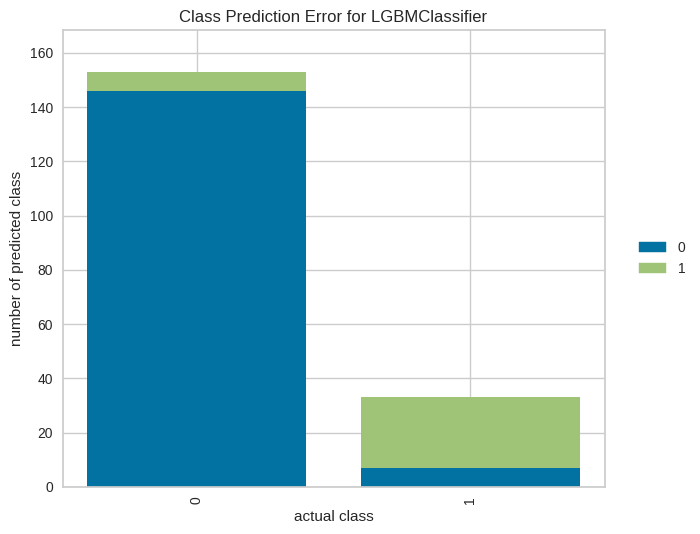

In [12]:
plot_model(lgbm, plot = 'error')

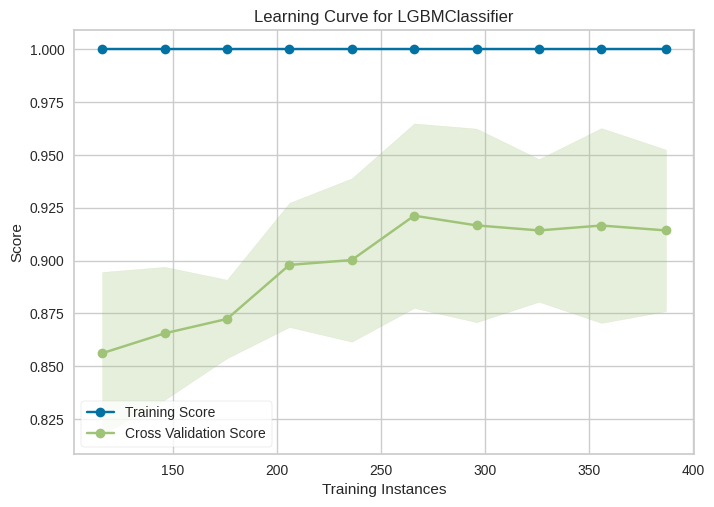

In [13]:
plot_model(lgbm, plot = 'learning')

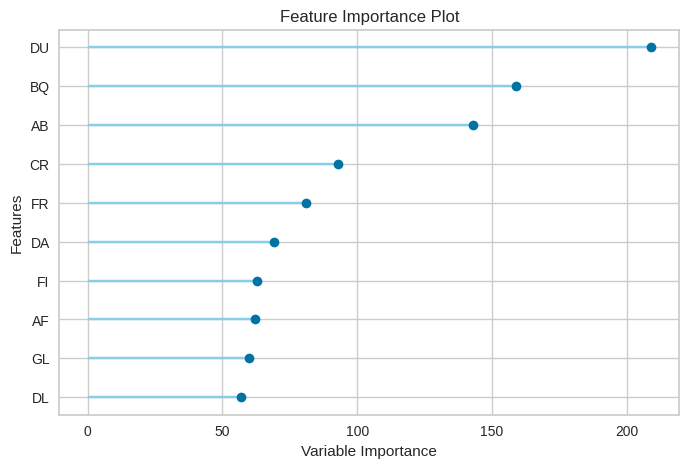

In [14]:
plot_model(lgbm, plot = 'feature')

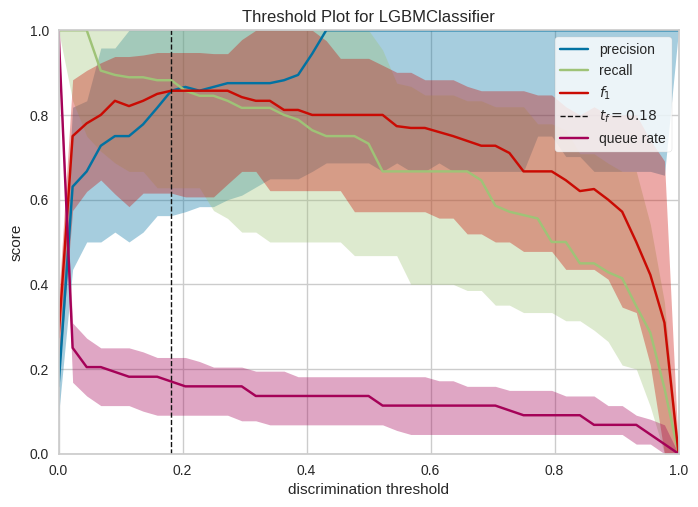

In [15]:
plot_model(lgbm, plot = 'threshold')

## <a name="52"></a><h1 style="font-size: 24px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #ffe1a8; color:#C9CBA3; text-align: center; border-radius: 50px 50px;"><b>CatBoost</b></h1> 

In [16]:
catb = create_model('catboost')
tuned_dt = tune_model(catb, optimize = 'logloss', n_iter=25)
warnings.filterwarnings('ignore')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8636,0.8924,0.6250,0.6250,0.6250,0.5417,0.5417,4.9150
1,0.9535,0.9524,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
2,0.9535,0.9921,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
3,0.9070,0.9563,0.4286,1.0000,0.6000,0.5567,0.6211,3.3529
4,0.9535,0.9722,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
5,0.9535,0.9921,0.8571,0.8571,0.8571,0.8294,0.8294,1.6764
6,0.9302,0.9857,0.6250,1.0000,0.7692,0.7307,0.7587,2.5147
7,0.8837,0.9607,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
8,0.8837,0.9786,0.5000,0.8000,0.6154,0.5511,0.5723,4.1911


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8409,0.8333,0.5000,0.5714,0.5333,0.4380,0.4394,5.7342
1,0.9535,0.9802,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
3,0.8837,0.9246,0.4286,0.7500,0.5455,0.4844,0.5094,4.1911
4,0.9070,0.9444,0.7143,0.7143,0.7143,0.6587,0.6587,3.3529
5,0.9302,0.9802,0.7143,0.8333,0.7692,0.7284,0.7314,2.5147
6,0.8837,0.9500,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
7,0.9070,0.9500,0.5000,1.0000,0.6667,0.6195,0.6699,3.3529
8,0.8837,0.9571,0.5000,0.8000,0.6154,0.5511,0.5723,4.1911


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### <a name="521"></a><h1 style="font-size: 18px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #C9CBA3; color:#ffffff; text-align: center; border-radius: 50px 50px;"> CatBoost evaluation</h1> 

In [17]:
plot_model(catb, plot = 'parameter')

,Parameters
nan_mode,Min
eval_metric,Logloss
iterations,1000
sampling_frequency,PerTree
leaf_estimation_method,Newton
grow_policy,SymmetricTree
penalties_coefficient,1
boosting_type,Plain
model_shrink_mode,Constant
feature_border_type,GreedyLogSum


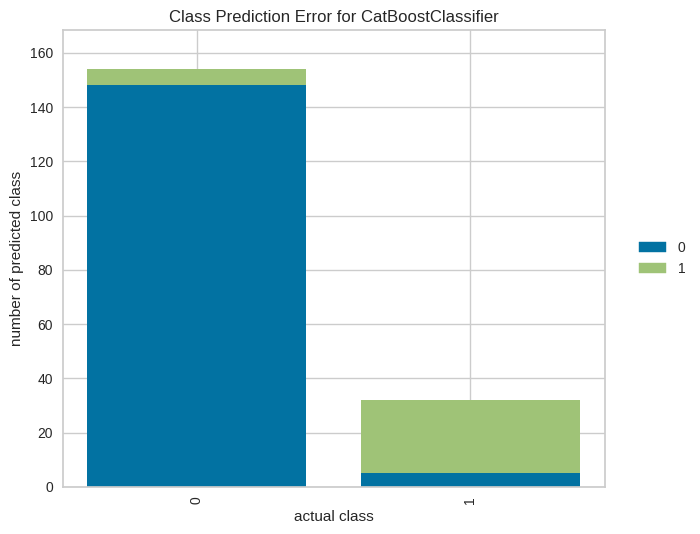

In [18]:
plot_model(catb, plot = 'error')

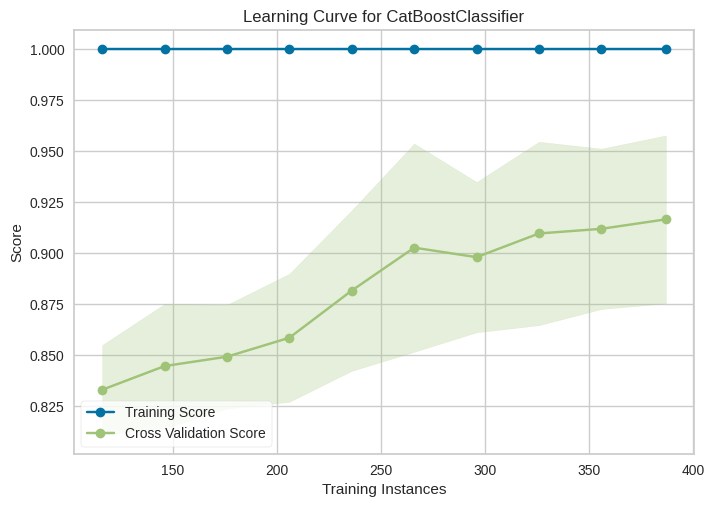

In [19]:
plot_model(catb, plot = 'learning')

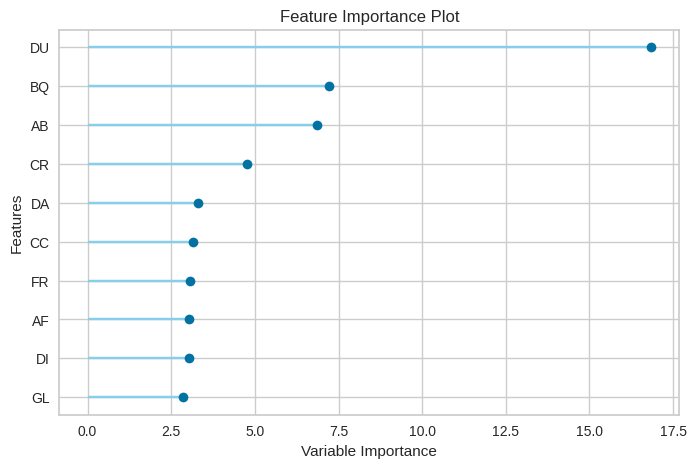

In [20]:
plot_model(catb, plot = 'feature')

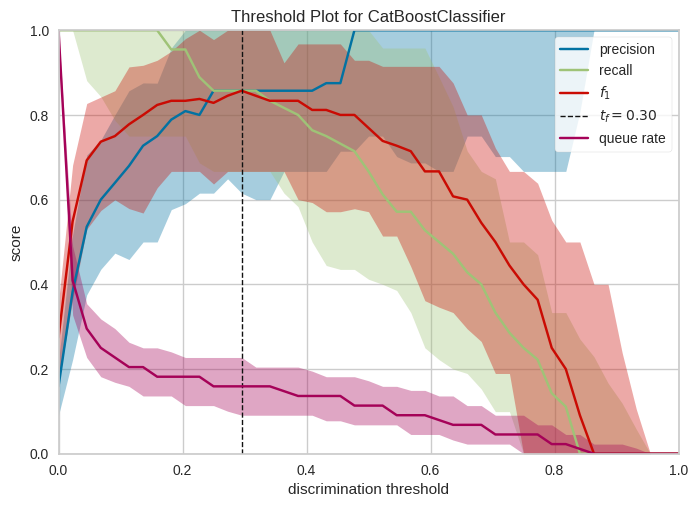

In [21]:
plot_model(catb, plot = 'threshold')

## <a name="53"></a><h1 style="font-size: 24px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #ffe1a8; color:#C9CBA3; text-align: center; border-radius: 50px 50px;"><b>XGBoost</b></h1> 

In [22]:
xgb = create_model('xgboost')
tuned_dt = tune_model(xgb, optimize = 'logloss', n_iter=25)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8409,0.8993,0.6250,0.5556,0.5882,0.4901,0.4914,5.7342
1,0.9535,0.9563,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
2,0.9302,0.9603,0.8571,0.7500,0.8000,0.7580,0.7605,2.5147
3,0.9070,0.9167,0.4286,1.0000,0.6000,0.5567,0.6211,3.3529
4,0.9535,0.9802,0.8571,0.8571,0.8571,0.8294,0.8294,1.6764
5,0.9767,1.0000,1.0000,0.8750,0.9333,0.9193,0.9223,0.8382
6,0.9070,0.9929,0.5000,1.0000,0.6667,0.6195,0.6699,3.3529
7,0.8837,0.9679,0.3750,1.0000,0.5455,0.4941,0.5728,4.1911
8,0.9302,0.9786,0.7500,0.8571,0.8000,0.7580,0.7605,2.5147


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Log Loss
Fold,,,,,,,,
0,0.8409,0.9028,0.8750,0.5385,0.6667,0.5698,0.5988,5.7342
1,0.9535,0.9762,0.8571,0.8571,0.8571,0.8294,0.8294,1.6764
2,0.8837,0.9802,1.0000,0.5833,0.7368,0.6687,0.7087,4.1911
3,0.9535,0.9841,0.7143,1.0000,0.8333,0.8072,0.8226,1.6764
4,0.9535,0.9762,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
5,0.9535,0.9921,1.0000,0.7778,0.8750,0.8470,0.8571,1.6764
6,0.9302,1.0000,0.6250,1.0000,0.7692,0.7307,0.7587,2.5147
7,0.9535,0.9607,0.7500,1.0000,0.8571,0.8300,0.8423,1.6764
8,0.9535,0.9821,0.8750,0.8750,0.8750,0.8464,0.8464,1.6764


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 25 candidates, totalling 250 fits


### <a name="531"></a><h1 style="font-size: 18px; font-family: 'Roboto Mono', monospace; font-weight: normal; background-color: #C9CBA3; color:#ffffff; text-align: center; border-radius: 50px 50px;"> XGBoost evaluation</h1> 

In [23]:
plot_model(xgb, plot = 'parameter')

,Parameters
objective,binary:logistic
use_label_encoder,None
base_score,None
booster,gbtree
callbacks,None
colsample_bylevel,None
colsample_bynode,None
colsample_bytree,None
early_stopping_rounds,None
enable_categorical,False


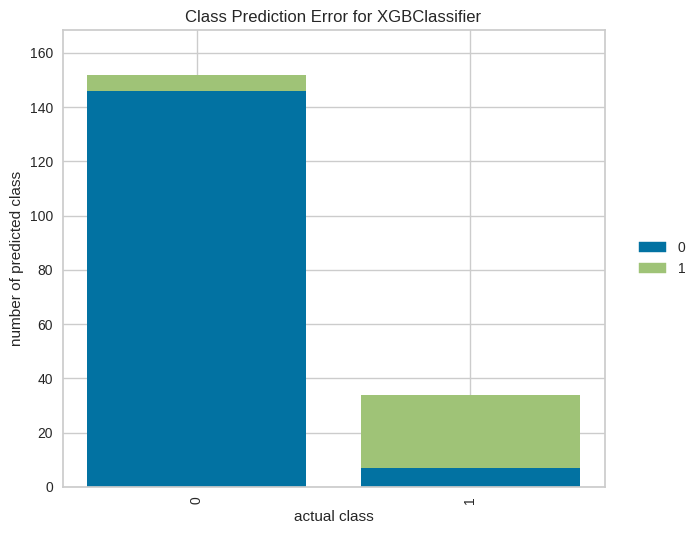

In [24]:
plot_model(xgb, plot = 'error')

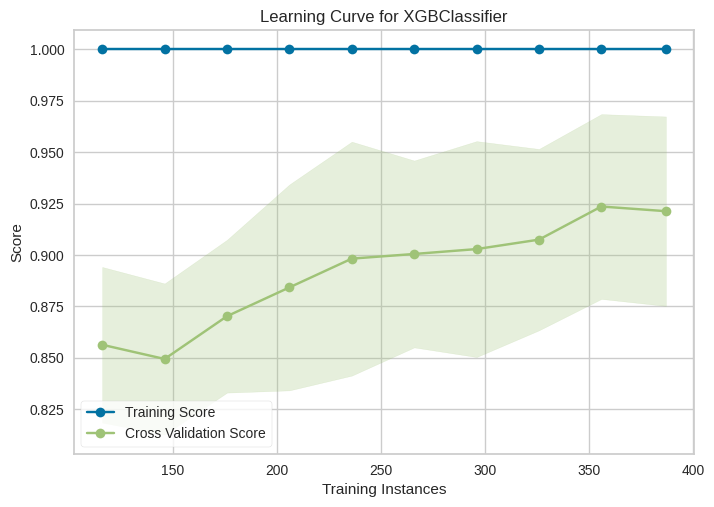

In [25]:
plot_model(xgb, plot = 'learning')

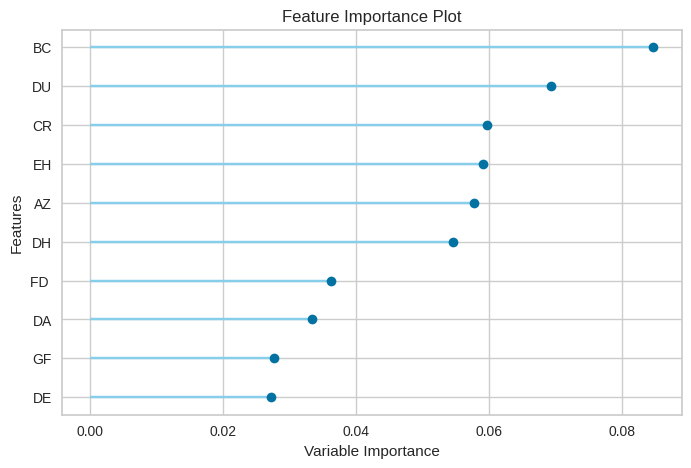

In [26]:
plot_model(xgb, plot = 'feature')

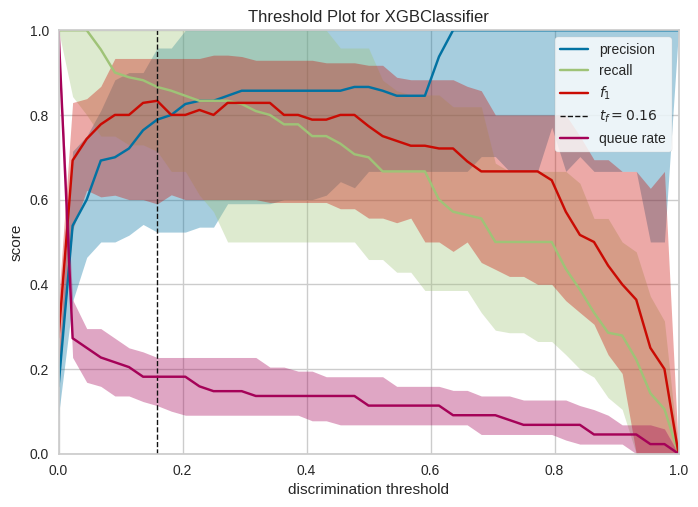

In [27]:
plot_model(xgb, plot = 'threshold')